# Market Regime Analysis

In this notebook, we analyze volatility regimes and study how market conditions transition between stable and risky states.

Objectives:
1. Identify volatility regimes
2. Analyze regime persistence
3. Visualize transitions between market states
4. Understand changing market risk conditions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
sp500 = pd.read_csv("../data/SP500_processed.csv", index_col="Date", parse_dates=True)
btc = pd.read_csv("../data/BTC_processed.csv", index_col="Date", parse_dates=True)

In [3]:
sp500["rolling_vol"] = (
    sp500["log_return"]
    .rolling(30)
    .std()
)

btc["rolling_vol"] = (
    btc["log_return"]
    .rolling(30)
    .std()
)

In [4]:
low_threshold = sp500["rolling_vol"].quantile(0.33)

high_threshold = sp500["rolling_vol"].quantile(0.66)

In [5]:
conditions = [
    sp500["rolling_vol"] <= low_threshold,
    
    sp500["rolling_vol"] <= high_threshold
]

choices = [
    "Stable",
    "Neutral"
]

sp500["Regime"] = np.select(
    conditions,
    choices,
    default="Risky"
)

In [6]:
sp500[["rolling_vol", "Regime"]].tail()

,rolling_vol,Regime
Date,,
2026-03-02,0.008130,Neutral
2026-03-03,0.008279,Neutral
2026-03-04,0.007472,Neutral
2026-03-05,0.007243,Neutral
2026-03-06,0.007543,Neutral


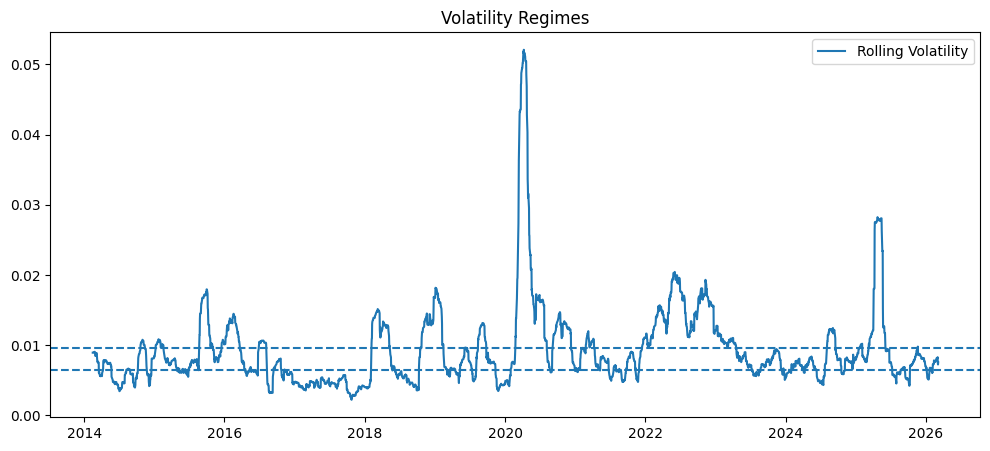

In [7]:
plt.figure(figsize=(12,5))

plt.plot(
    sp500["rolling_vol"],
    label="Rolling Volatility"
)

plt.axhline(
    low_threshold,
    linestyle="--"
)

plt.axhline(
    high_threshold,
    linestyle="--"
)

plt.legend()

plt.title("Volatility Regimes")

plt.show()

## Regime Interpretation

- Stable regime corresponds to relatively calm market conditions
- Neutral regime indicates moderate uncertainty
- Risky regime reflects elevated market instability and stress

These regimes will later guide adaptive trading exposure decisions.

In [8]:
regime_counts = sp500["Regime"].value_counts()

regime_counts

Regime
Risky      1060
Stable     1001
Neutral    1000
Name: count, dtype: int64

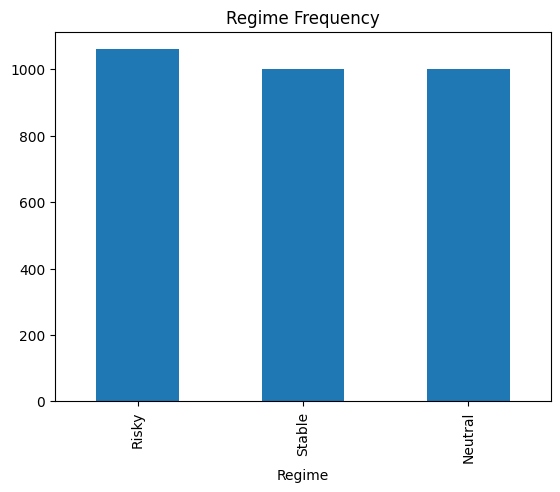

In [9]:
regime_counts.plot(kind="bar")

plt.title("Regime Frequency")

plt.show()

In [10]:
regime_transitions = pd.crosstab(
    sp500["Regime"].shift(1),
    sp500["Regime"]
)

regime_transitions

Regime,Neutral,Risky,Stable
Regime,,,
Neutral,931,19,49
Risky,21,1039,0
Stable,48,1,952


## Regime Persistence

Market regimes often persist over time rather than changing randomly every period.

Volatility clustering causes risky periods and stable periods to occur in persistent clusters.

# Conclusion

Volatility regimes provide a useful representation of changing market risk conditions.

These regimes can be integrated into adaptive trading systems to dynamically control exposure during stable and risky market environments.

## Regime Interpretation

The market alternates between calm and turbulent volatility states.

High-volatility regimes correspond to periods of uncertainty, market stress, and increased downside risk.

BTC typically exhibits more frequent and persistent high-volatility regimes compared to SP500.